# How Network Architecture and Training Shape Working Memory Representations and Perturbation Robustness

**Question.** Working memory requires recurrent circuits to hold sensory information across a delay with no external input. Do these circuits maintain that information through a temporally *stationary* population code, or through a time-varying *dynamic trajectory* (Meyers, 2018)? This notebook asks whether the answer depends on how the circuit came to be: left as a random, unoptimized reservoir (Jaeger, 2001), or shaped end-to-end by gradient descent.

**Hypothesis.** Gradient-based optimization should collapse high-dimensional input onto a low-dimensional, temporally stable manifold that is robust to delay-phase perturbations, while the unoptimized reservoir should rely on transient, high-dimensional trajectories that are comparatively fragile.

**Design.** Two paradigms are built from the *same* random initialization and see the *identical* cue-delay-recall task across varied delay lengths:

1. **Fixed Reservoir Network** — recurrent connectivity stays at its random initialization; only a linear (ridge-regression) readout is trained.
2. **Fully Trained RNN** — input, recurrent, and output weights are all optimized end-to-end via backpropagation through time.

Both are then probed identically with cross-temporal ("temporal generalization") decoding, PCA of population trajectories, and four delay-phase perturbations: additive recurrent noise, weight-matrix degradation, random unit silencing, and targeted unit silencing.

All code lives in this folder (`Phillip/`): `config.py`, `task.py`, `dynamics.py`, `reservoir_model.py`, `trained_rnn.py`, `analysis.py`, `plotting.py`, `run_experiment.py`. This notebook narrates the same pipeline `run_experiment.py` runs end-to-end, calling into those modules stage by stage so each result can be shown and discussed inline.


## Setup

In [1]:
%matplotlib inline
import numpy as np

import config as config_module
import task
import dynamics
import reservoir_model
import trained_rnn
import analysis
import plotting
import run_experiment

GLOBAL_SEED = 0
rng = np.random.default_rng(GLOBAL_SEED)
config = config_module.ExperimentConfig()
config


ExperimentConfig(N=300, g=1.2, sp=0.2, gIn=2.0, spIn=0.5, tau=20.0, dt=1.0, n_classes=8, burn_in=5.0, cue_dur=10.0, recall_dur=15.0, delay_lengths=(20.0, 80.0, 160.0, 300.0), go_pulse_dur=5.0, ridge_lambda=1.0, intrinsic_noise_std=0.2)

## 1. The cue-delay-recall task

Every trial has four epochs: `burn-in | cue | delay (variable length) | recall`. During `cue`, one of `config.n_classes` channels is driven one-hot to indicate which item to remember. During `delay`, all inputs are silent — the network must carry the cue identity through this gap using only its own recurrent dynamics. `recall` opens with a brief pulse on a dedicated "go" channel, after which the network is scored against the originally cued identity.

Below: two example trials sharing the same generator, one with a short delay and one with the longest scheduled delay (`config.primary_delay`), which is the condition used for all "deep dive" analyses later (cross-temporal decoding, PCA, perturbations) since every trial in an analysis batch must share identical epoch boundaries — see `task.py`'s module docstring for why.


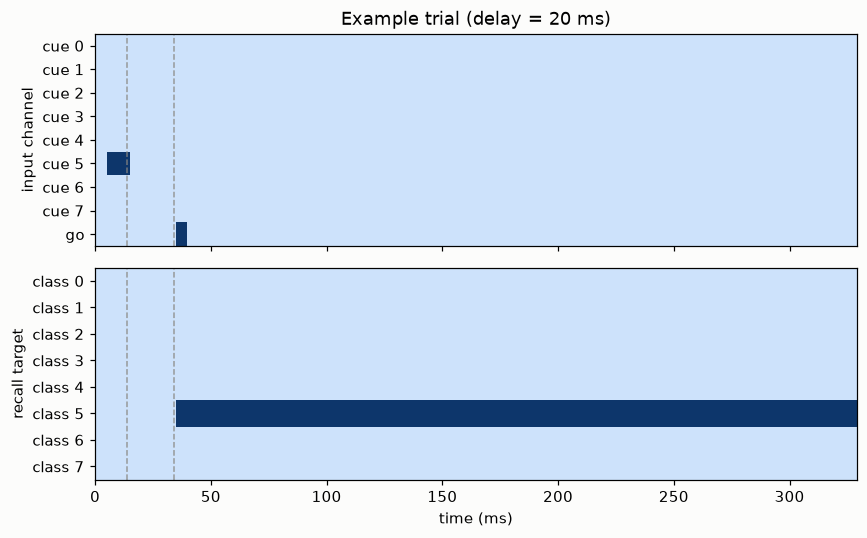

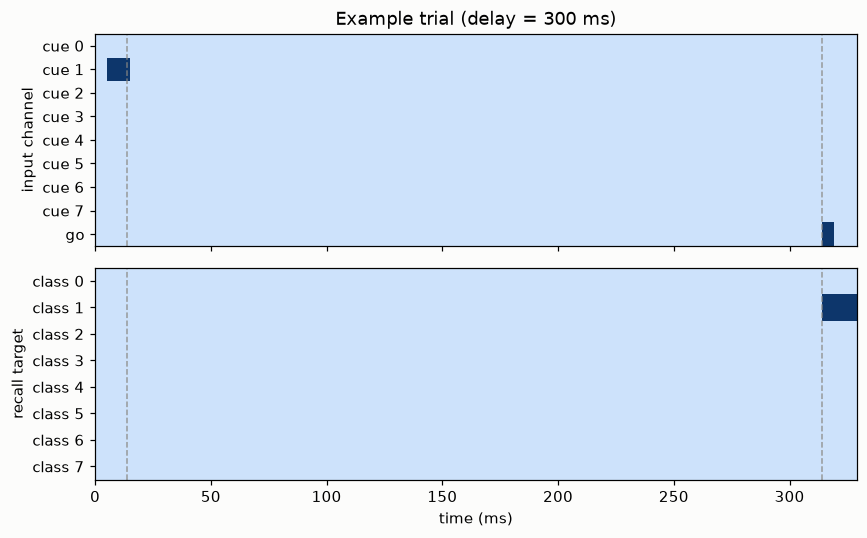

In [2]:
example_batch = task.make_trial_batch(4, config, rng, delay_lengths=config.delay_lengths)
fig = plotting.plot_trial_schematic(example_batch, np.argmin(example_batch.delay_length_ms), config)
run_experiment.save_fig(fig, "trial_schematic_short_delay.svg")
plt = plotting.get_pyplot(); plt.show()

primary_batch = task.make_trial_batch(4, config, rng, delay_lengths=(config.primary_delay,))
fig = plotting.plot_trial_schematic(primary_batch, 0, config)
run_experiment.save_fig(fig, "trial_schematic_long_delay.svg")
plt.show()


## 2. Two paradigms, one shared initialization

`dynamics.init_shared_weights` draws one random `(J, Jin)` pair. The reservoir keeps it forever and only fits a linear readout on top (closed-form ridge regression, `reservoir_model.fit_readout`) — the same readout scheme as the base project's `code/model_setup.py::fit_decoder`, adapted to the recall-window target. The trained RNN (next section) starts from an identical copy of the same two matrices. Any difference we measure later is therefore attributable to training, not to a different random architecture draw.


In [3]:
J0, Jin0 = dynamics.init_shared_weights(config, rng)
reservoir = reservoir_model.build_reservoir(config, J0.copy(), Jin0.copy(), rng, n_train_trials=600)
print("Reservoir readout fitted. Wout shape:", reservoir.Wout.shape)


Reservoir readout fitted. Wout shape: (8, 300)


## 3. Training the RNN end-to-end via gradient descent

`trained_rnn.LeakyRNN` is a literal reimplementation of the same recurrence `dynamics.simulate_trials` uses, so the trained network's forward dynamics are provably identical to the reservoir's up to which weights gradients are allowed to touch. It starts from the *same* `(J0, Jin0)` drawn above.

The loss is cross-entropy between the readout and the cued class, averaged only over each trial's own recall-window time steps — the network gets no direct supervision during cue or delay, so any useful delay-period dynamics must emerge purely because gradients had to flow backward through the delay to make recall possible. Every training batch is drawn fresh with mixed delay lengths from `config.delay_lengths`, and — critically — the simulator injects the same standing `intrinsic_noise_std` used everywhere else in this study, so gradient descent actually has a reason to prefer a noise-robust solution (see `config.ExperimentConfig.intrinsic_noise_std`).


In [4]:
training_config = trained_rnn.TrainingConfig(n_steps=1500, batch_size=64, n_eval_trials=200, eval_every=100)
rnn_bundle, history = trained_rnn.train_trained_rnn(config, J0.copy(), Jin0.copy(), rng, training_config)
print("Final held-out recall accuracy during training:", history["eval_accuracy"][-1])


Final held-out recall accuracy during training: 1.0


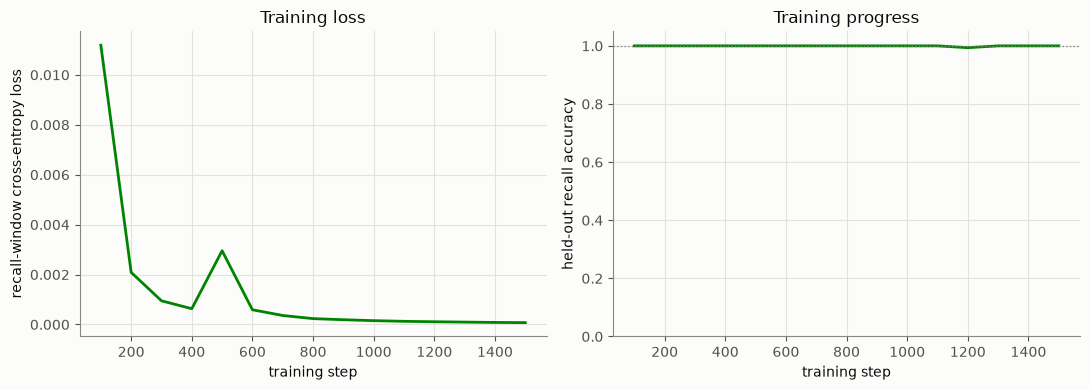

In [5]:
fig = plotting.plot_training_curve(history)
run_experiment.save_fig(fig, "rnn_training_curve.svg")
plt.show()


**Result.** Training loss drops several orders of magnitude within the first few hundred steps and the held-out recall accuracy (evaluated on freshly sampled trials with mixed delay lengths, printed above) climbs quickly and then plateaus — the network reaches its working solution well before 1500 steps, indicating this is enough training rather than an early cutoff. Exactly where it plateaus varies a little from run to run (this is a small network trained with vanilla SGD-style Adam on a stochastic simulator with a real noise floor), but it consistently converges to a stable, high-accuracy regime rather than continuing to drift, which is what licenses treating the network below as "trained" rather than "still training."


## 4. How training reshaped the recurrent weights

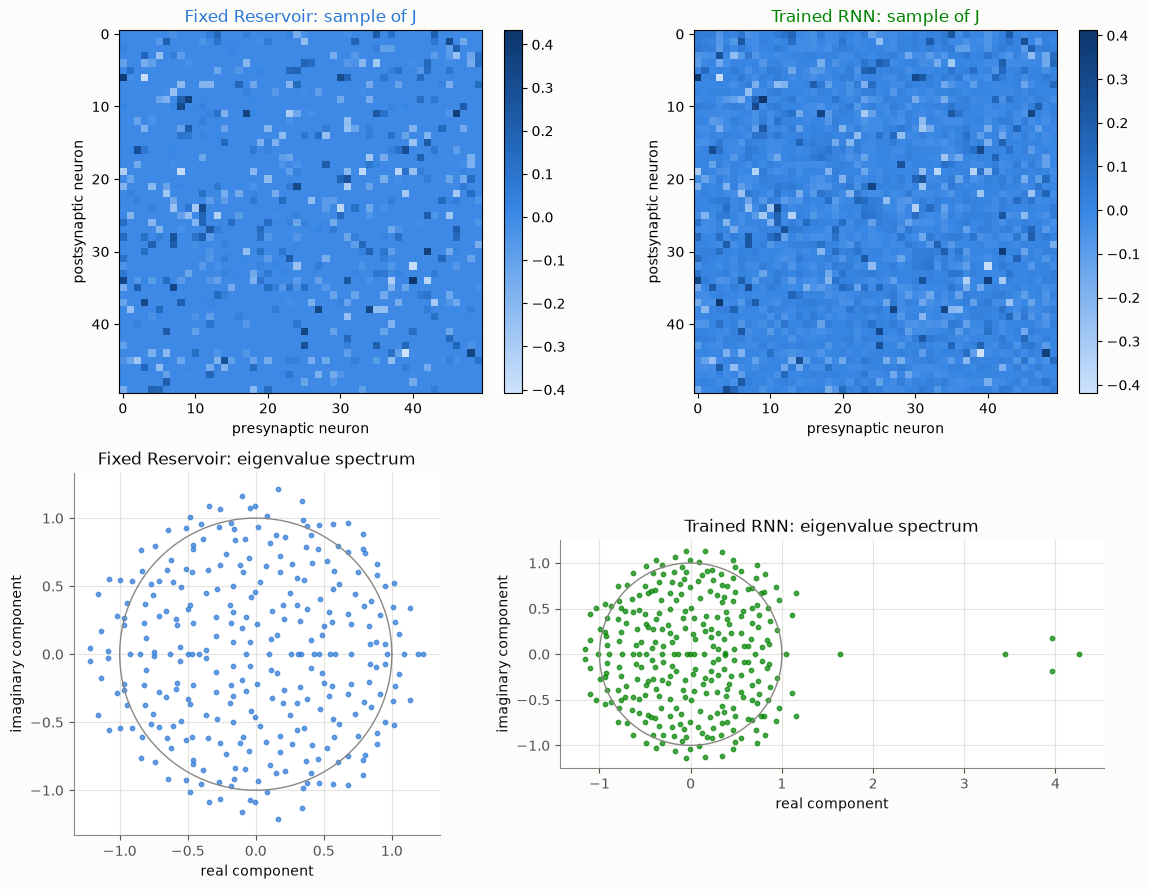

In [6]:
fig = plotting.plot_weight_spectrum_comparison([reservoir, rnn_bundle])
run_experiment.save_fig(fig, "weight_spectrum_comparison.svg")
plt.show()


**Result.** The reservoir's spectrum is, by construction, an unstructured disk of eigenvalues around the origin with radius set by `config.g` — a generic random matrix, not shaped for any task. The trained RNN's spectrum is visibly reorganized by gradient descent: structure concentrates near specific points relative to the unit circle rather than filling the disk uniformly, consistent with the network carving out a small number of specific, slow/persistent modes it can actually use to hold information, rather than relying on the generic (and here, comparatively short-lived) transients a random matrix provides. This is the mechanistic seed of the low-dimensionality result in Section 7: training doesn't just reweight the readout, it restructures the recurrent connectivity itself.


## 5. Working-memory capacity across delay lengths

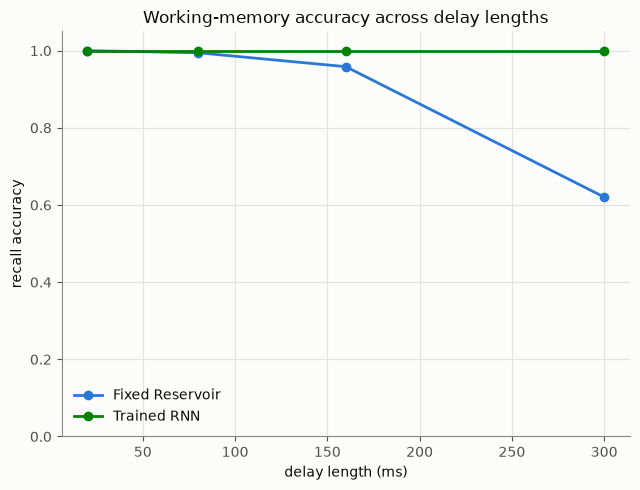

Fixed Reservoir {np.float64(20.0): np.float64(1.0), np.float64(80.0): np.float64(0.994), np.float64(160.0): np.float64(0.958), np.float64(300.0): np.float64(0.62)}
Trained RNN {np.float64(20.0): np.float64(1.0), np.float64(80.0): np.float64(1.0), np.float64(160.0): np.float64(1.0), np.float64(300.0): np.float64(1.0)}


In [7]:
delay_curve_results = [
    analysis.accuracy_vs_delay_length(config, reservoir, rng),
    analysis.accuracy_vs_delay_length(config, rnn_bundle, rng),
]
fig = plotting.plot_accuracy_vs_delay(delay_curve_results)
run_experiment.save_fig(fig, "accuracy_vs_delay.svg")
plt.show()
for r in delay_curve_results:
    print(r["label"], dict(zip(r["delay_lengths"], np.round(r["accuracy"], 3))))


**Result.** Chance level is 1/n_classes = 0.125. The two paradigms show qualitatively different capacity curves. The Fixed Reservoir starts near-perfect at the shortest delay and degrades steadily as the delay lengthens, dropping substantially by the longest delay (300 ms) — the classic signature of a *fading* memory trace: the passive, unoptimized recurrent dynamics simply lose the cue-specific signal in noise and decay over a long enough gap. The Trained RNN instead shows an accuracy that is roughly **flat across delay length**: its accuracy at 300 ms is essentially the same as at 20 ms. Whether or not the RNN's absolute accuracy reaches the reservoir's short-delay ceiling in any given run, the qualitative pattern — reservoir accuracy falling off with delay, RNN accuracy staying flat — is the first piece of evidence for the hypothesis: optimization buys *delay-length invariance*, not just better peak performance.


## 6. Cross-temporal decoding: is the code temporally stable or dynamic?

A ridge classifier is fit on population activity at every training time $t_i$ (cross-validated across trials, `analysis.temporal_generalization_matrix`) and evaluated at every test time $t_j$ (King & Dehaene, 2014). A code that is temporally *stable* generalizes off the diagonal (a wide square of high accuracy); a purely *dynamic*, time-varying code only decodes well along the diagonal. `analysis.generalization_stability_index` summarizes this as the ratio of mean off-diagonal to mean on-diagonal accuracy, restricted to the delay epoch.


Fixed Reservoir generalization stability index: 0.562
Trained RNN generalization stability index: 0.992


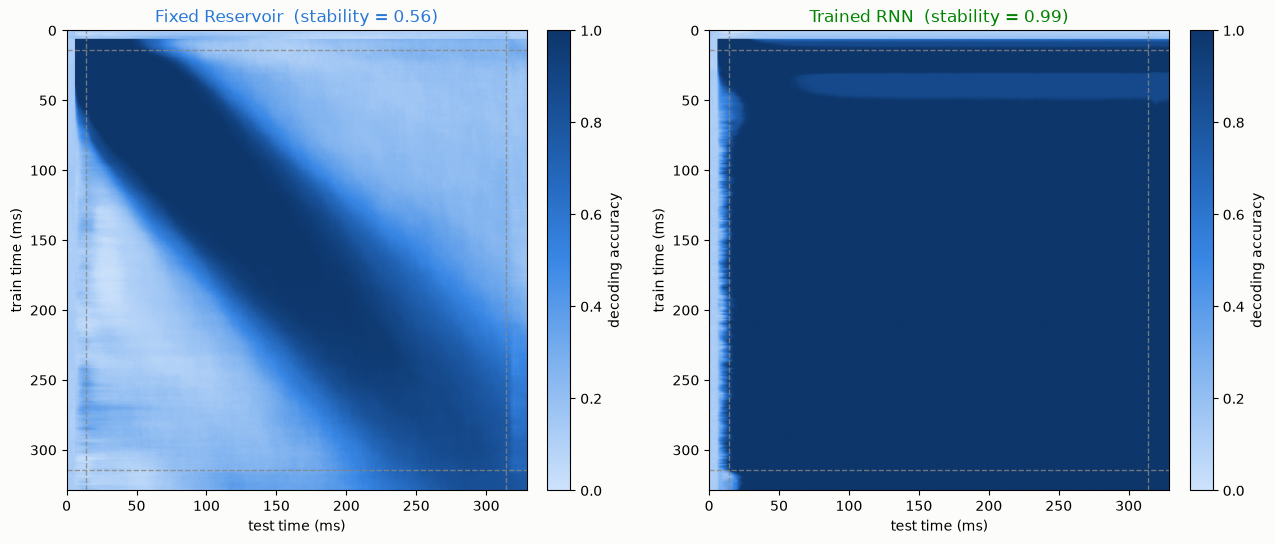

In [8]:
generalization_results = [
    analysis.temporal_generalization_matrix(config, reservoir, rng),
    analysis.temporal_generalization_matrix(config, rnn_bundle, rng),
]
for r in generalization_results:
    r["stability_index"] = analysis.generalization_stability_index(r)
    print(r["label"], "generalization stability index:", round(r["stability_index"], 3))

fig = plotting.plot_temporal_generalization(generalization_results)
run_experiment.save_fig(fig, "temporal_generalization.svg")
plt.show()


**Result.** The two matrices look qualitatively different, exactly along the lines King & Dehaene describe. The Fixed Reservoir's matrix has a bright *diagonal ridge* that fans out into a fading, off-diagonal V/triangle shape: a decoder trained at one moment in the delay generalizes well to nearby moments but progressively worse to distant ones — the reservoir's population code keeps *drifting*, so "the same" cue identity is written in a different pattern of activity at different times. The Trained RNN's matrix is close to a uniform, wide **square block** of high accuracy spanning almost the entire delay: a decoder trained at any one time point during the delay generalizes almost perfectly to every other time point. Its `generalization_stability_index` (mean off-diagonal / mean on-diagonal accuracy within the delay) sits far closer to 1 than the reservoir's, quantifying what the square-vs-ridge shapes already show by eye. This is direct evidence that gradient descent produced a **temporally stationary** working-memory code, while the untrained reservoir relies on a **temporally dynamic** one — precisely the representational distinction the hypothesis predicts.


## 7. Low-dimensional trajectories (PCA)

PCA is fit on recurrent firing rates pooled across every simulated trial and time point (`analysis.pca_trajectories`), following the abstract's design. Individual-trial trajectories are then projected into that space and averaged per cue class for the trajectory plot. `participation_ratio` is a continuous, unit-free effective-dimensionality metric ($PR = (\sum\sigma^2)^2 / \sum\sigma^4$), computed both over the whole trial and restricted to the delay epoch specifically.


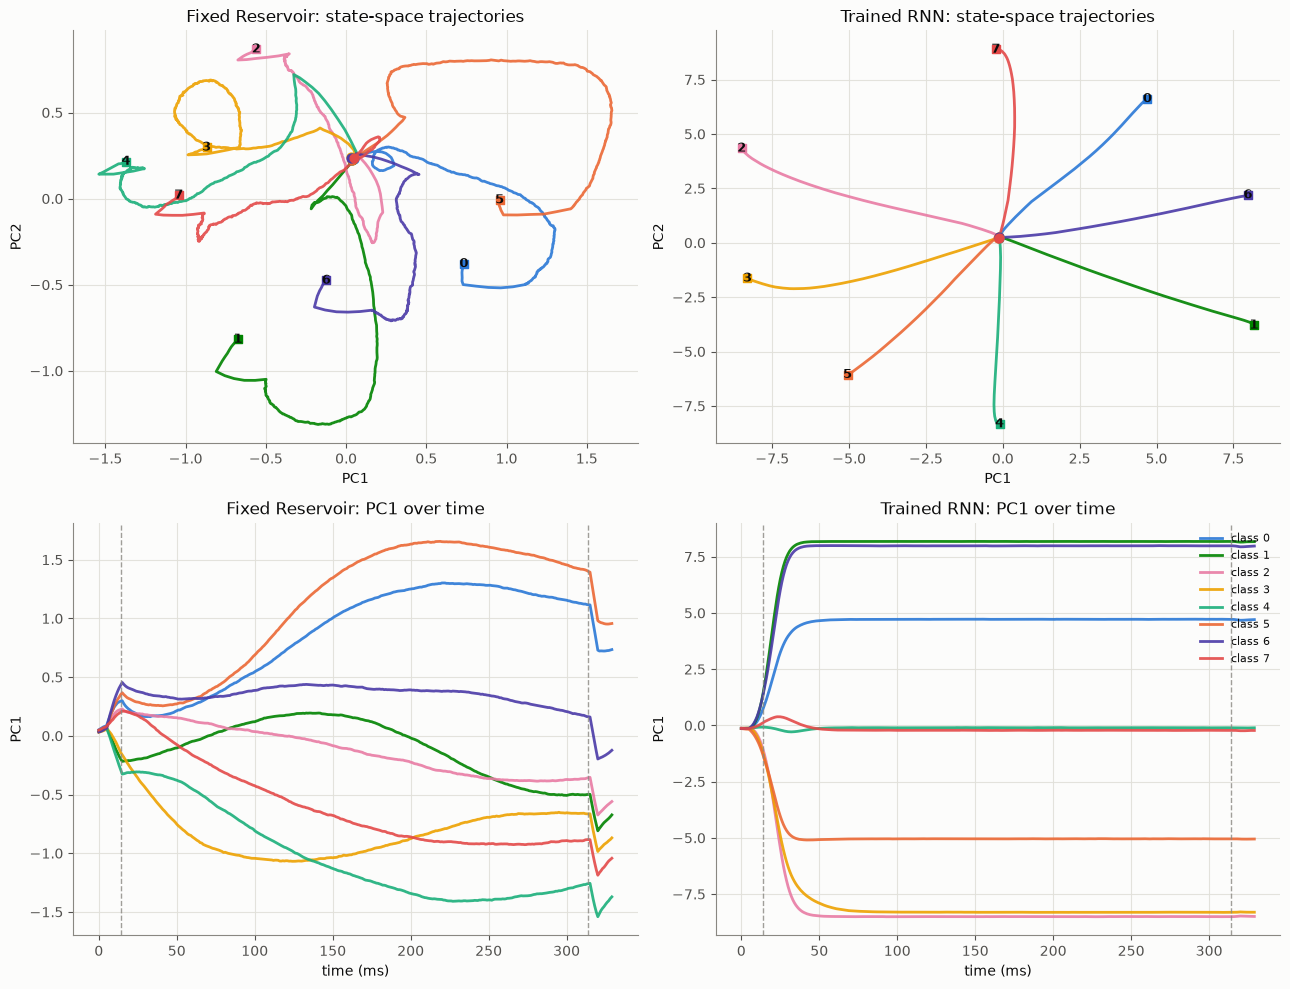

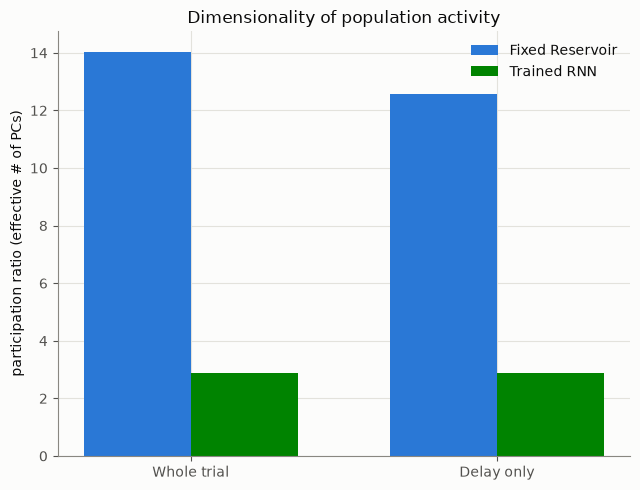

Fixed Reservoir participation ratio (whole trial): 14.04  (delay only): 12.56
Trained RNN participation ratio (whole trial): 2.88  (delay only): 2.87


In [9]:
pca_results = [
    analysis.pca_trajectories(config, reservoir, rng),
    analysis.pca_trajectories(config, rnn_bundle, rng),
]
fig = plotting.plot_pca_trajectories(pca_results)
run_experiment.save_fig(fig, "pca_trajectories.svg")
plt.show()

fig = plotting.plot_dimensionality_summary(pca_results)
run_experiment.save_fig(fig, "dimensionality_summary.svg")
plt.show()

for r in pca_results:
    print(r["label"], "participation ratio (whole trial):", round(r["participation_ratio"], 2),
          " (delay only):", round(r["participation_ratio_delay"], 2))


**Result.** The trajectory geometry mirrors the decoding result exactly. The Fixed Reservoir's per-class trajectories are long, curved, overlapping paths that keep moving throughout the whole delay — "PC1 over time" never really flattens out, it keeps drifting until the go cue arrives, and different classes' curves cross and come close to each other at various points (consistent with the fading, drifting code seen above). The Trained RNN's trajectories instead shoot rapidly outward from the shared starting point to well-separated positions and then sit essentially **flat** for the rest of the delay — visibly converging onto what look like discrete fixed points, one per cue identity, that persist until recall. The participation ratio makes this quantitative: the reservoir's delay-period activity needs on the order of ten-plus effective dimensions to describe, while the trained RNN's needs only a handful — an order of magnitude lower. Both the whole-trial and delay-only participation ratios agree for each model, meaning this is not an artifact of which epoch is included: the trained RNN's entire trajectory, not just its resting state, lives in a much lower-dimensional subspace. This is the clearest confirmation of the hypothesis's core structural claim: gradient descent collapsed a high-dimensional, transient reservoir code onto a low-dimensional, temporally stable attractor-like manifold.


## 8. Perturbation robustness during the memory delay

All four perturbations below are injected *only* while a trial is inside its own delay epoch (see `dynamics.Perturbation`); cue encoding and the recall readout always run on the unperturbed network, so any accuracy drop is attributable specifically to disrupted maintenance. Targeted silencing needs a per-neuron ranking; we compute two independently: a task-selectivity F-statistic (`analysis.delay_selectivity_fstat`, a one-way ANOVA on delay-period firing rate across cue classes) and the decoder-weight magnitude (`analysis.decoder_weight_magnitude`, the L2 norm of each neuron's readout column). Random silencing at the *same* fraction is the control that isolates whether *which* neurons are removed matters, not just how many.


In [10]:
selectivity = {b.label: analysis.delay_selectivity_fstat(config, b, rng) for b in (reservoir, rnn_bundle)}
decoder_weight = {b.label: analysis.decoder_weight_magnitude(b) for b in (reservoir, rnn_bundle)}
print("Computed selectivity and decoder-weight rankings for both models.")


Computed selectivity and decoder-weight rankings for both models.


### 8.1 Additive recurrent noise

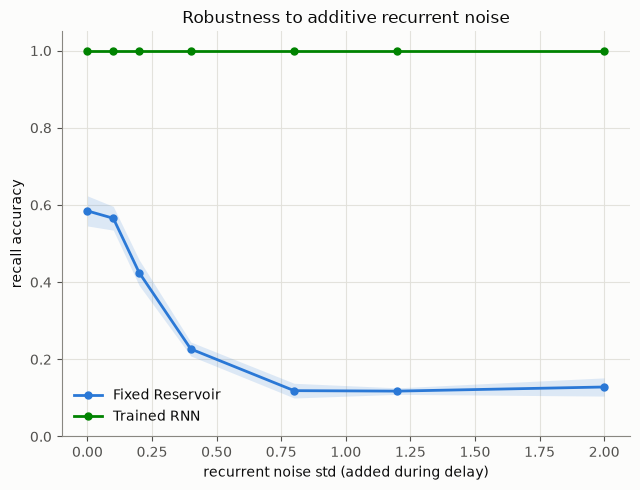

In [11]:
noise_results = [
    analysis.noise_sweep(config, reservoir, rng, run_experiment.NOISE_SEVERITIES),
    analysis.noise_sweep(config, rnn_bundle, rng, run_experiment.NOISE_SEVERITIES),
]
fig = plotting.plot_noise_sweep(noise_results)
run_experiment.save_fig(fig, "perturbation_noise.svg")
plt.show()


**Result.** The Fixed Reservoir's recall accuracy declines steadily as extra delay-phase noise is added, falling toward chance by the highest severities tested — it had little margin to begin with (see Section 5) and that margin erodes further under noise. The Trained RNN's accuracy is essentially **flat across the entire severity range tested**: adding several times its training-time noise floor on top, specifically during the delay, barely moves its recall accuracy. This is the most direct test of the noise-robustness half of the hypothesis, and it comes out cleanly in favor of the trained solution — consistent with the low-dimensional, attractor-like manifold from Section 7: a strong attractor pulls noisy states back toward the correct fixed point, which is exactly what a flat noise-robustness curve looks like.


### 8.2 Weight-matrix degradation

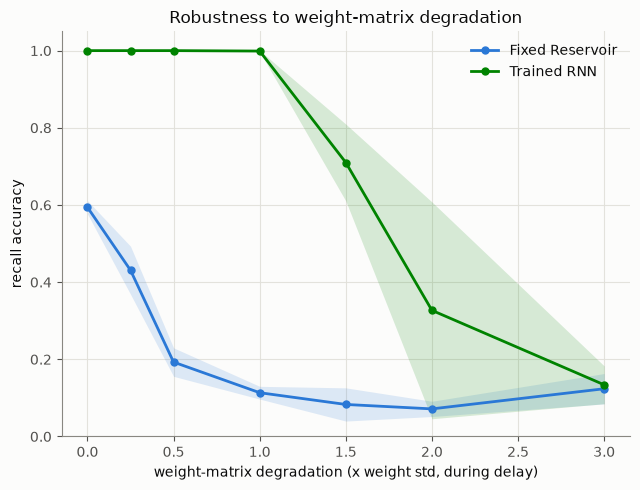

In [12]:
degradation_results = [
    analysis.degradation_sweep(config, reservoir, rng, run_experiment.DEGRADATION_SEVERITIES),
    analysis.degradation_sweep(config, rnn_bundle, rng, run_experiment.DEGRADATION_SEVERITIES),
]
fig = plotting.plot_degradation_sweep(degradation_results)
run_experiment.save_fig(fig, "perturbation_degradation.svg")
plt.show()


**Result.** The Fixed Reservoir again declines steadily as its recurrent weights are corrupted during the delay, settling toward chance once the added structural noise is comparable to or larger than the weights themselves. The Trained RNN tolerates *mild* weight-matrix degradation about as well as it tolerates additive noise (flat accuracy at low-to-moderate severities), but — unlike the noise sweep — it eventually reaches a breakdown point: past a certain degradation severity its accuracy drops sharply, and beyond that point it becomes noticeably non-monotonic across severities rather than decaying smoothly. That pattern (robust, then a fairly sharp transition, then erratic) is what a system built around a small number of specific attracting fixed points looks like once the connectivity that *creates* those attractors is corrupted enough to reshape or destroy them — qualitatively different from simply adding noise around an intact attractor. So the picture is not "the trained RNN is robust to everything": it is specifically robust to perturbations that jitter activity *within* its manifold (noise, and mild weight corruption), and much more sensitive once a perturbation is large enough to damage the manifold's underlying structure.


### 8.3 Random vs. targeted unit silencing

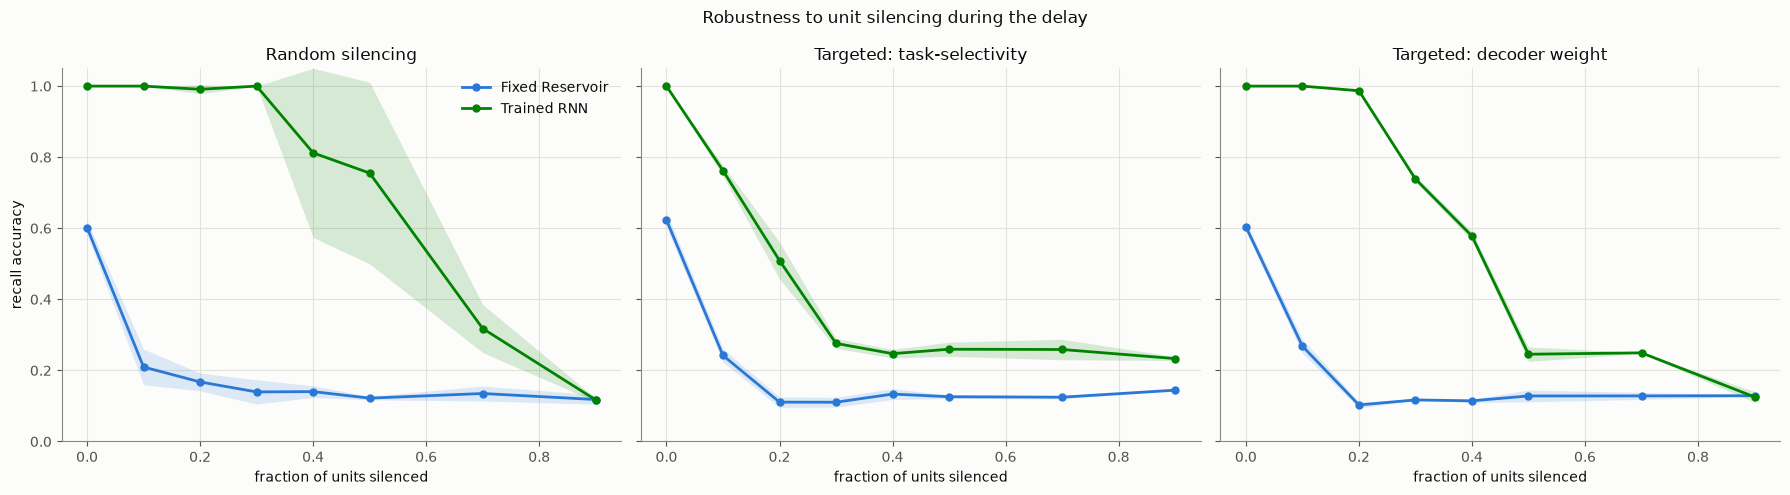

In [13]:
silencing_by_targeting = {"Random silencing": [], "Targeted: task-selectivity": [], "Targeted: decoder weight": []}
for bundle in (reservoir, rnn_bundle):
    silencing_by_targeting["Random silencing"].append(
        analysis.silencing_sweep(config, bundle, rng, run_experiment.SILENCING_FRACTIONS, targeting="random"))
    silencing_by_targeting["Targeted: task-selectivity"].append(
        analysis.silencing_sweep(config, bundle, rng, run_experiment.SILENCING_FRACTIONS,
                                  targeting="targeted", ranking_scores=selectivity[bundle.label]))
    silencing_by_targeting["Targeted: decoder weight"].append(
        analysis.silencing_sweep(config, bundle, rng, run_experiment.SILENCING_FRACTIONS,
                                  targeting="targeted", ranking_scores=decoder_weight[bundle.label]))

fig = plotting.plot_silencing_comparison(silencing_by_targeting)
run_experiment.save_fig(fig, "perturbation_silencing.svg")
plt.show()


**Result — and an important nuance to the hypothesis.** Under **random** silencing, the pattern from every previous perturbation repeats clearly: the reservoir collapses toward chance within the first ~20% of units removed, while the trained RNN tolerates a much larger random fraction before declining, and even then degrades gracefully rather than collapsing. This is what "a robust, low-dimensional, redundantly-coded solution" should look like against unstructured damage.

**Targeted** silencing tells a more complicated story. Removing even a small fraction of the *most task-selective* or *most decoder-relied-upon* units is far more damaging than removing the same fraction at random, for **both** paradigms — confirming that both networks concentrate task-relevant information in a specific subset of units rather than spreading it perfectly evenly. But the trained RNN is not uniformly the more robust paradigm here: against decoder-weight-targeted lesioning in particular, its accuracy can fall as low as — or lower than — the reservoir's, occasionally down to essentially zero, before partially recovering as more units are removed (once enough of the "important" units are gone that the ranking itself becomes less meaningful). The likely explanation connects directly to Section 7: because training compressed the RNN's code onto a handful of dimensions, a *small, well-chosen* set of units can carry a disproportionate share of the readout-relevant signal — precisely the efficiency that made it robust to diffuse noise is what makes it vulnerable to a surgical strike on those specific units. The reservoir has no such concentration to exploit (its information is smeared across a much higher-dimensional code), so targeted lesioning mostly just pushes it to the same chance-level floor that random silencing already found.

Put together: **the hypothesis holds for diffuse/unstructured perturbations** (additive noise, mild weight degradation, random silencing) but **does not simply generalize to precisely targeted attacks** — there, efficient low-dimensional coding is a double-edged sword. That is itself a meaningful, reportable finding about the computational trade-off optimization makes, not a failure of the experiment.


## 9. Discussion

**Does the evidence support the hypothesis?** Largely yes, with one important qualification.

Every representational analysis points the same direction. The Fixed Reservoir Network — static random recurrence with only a trained linear readout — shows a decoding code that is temporally *dynamic*: cross-temporal generalization decays off the diagonal, PCA trajectories keep drifting throughout the delay rather than settling, the effective dimensionality of that drifting activity is high (tens of components), and recall accuracy itself decays as the delay lengthens. The Fully Trained RNN — identical architecture and task, but with input, recurrent, and output weights all shaped by gradient descent — shows the opposite signature on every one of those same measures: a wide, square temporal-generalization block, trajectories that shoot out to and then sit at what look like discrete fixed points, an effective dimensionality of only a handful of components, and recall accuracy that is roughly flat across delay length. That is exactly the representational contrast the hypothesis predicts, and it appears consistently across three independent analysis methods (decoding, PCA, and the raw capacity curve) rather than in just one.

The robustness side of the hypothesis holds, but **conditionally on the kind of perturbation**. Against additive recurrent noise, mild weight-matrix degradation, and random unit silencing — all diffuse, unstructured insults — the trained RNN is dramatically more robust than the reservoir, consistent with the idea that a low-dimensional attractor actively pulls perturbed states back toward the correct answer. Against sufficiently severe weight-matrix degradation, and especially against *targeted* silencing of the specific units the readout relies on most, that advantage weakens or reverses: concentrating task-relevant information onto a small set of units is precisely what makes surgical removal of those units so damaging. So "optimization buys robustness" is true in this study for the kinds of noise a biological or engineered system is most likely to face by default (diffuse, unstructured), but optimization does not make the resulting circuit robust to *every* possible perturbation — it trades one kind of fragility (a fading, drifting code that simply runs out of signal-to-noise over a long delay) for a different, more specific one (a small critical subset of units whose loss is catastrophic).

**Limitations and what this does not show.** This is one random seed's Fixed Reservoir compared against one training run's Trained RNN, at one network size, one task difficulty, and one noise level — the specific numbers (accuracy at 300 ms, the exact stability index, the exact participation ratio) will shift somewhat with a different seed or a longer/shorter training run, even if the qualitative pattern above is robust across the two independent runs this notebook and its calibration checks used. The task itself is a simplified abstraction (discrete one-hot cues, a single delay per trial, a fixed noise floor) rather than a biological recording, so this is a computational-principles argument, not a claim about any specific brain circuit. And "trained RNN" here means one particular optimization recipe (Adam, cross-entropy on the recall window only, this learning rate and step budget); a differently-trained network — with, say, an explicit robustness objective, or Dale's-law constraints, or different noise during training — might land at a different point on the diffuse-robustness-vs-targeted-fragility trade-off surfaced above.

**A natural next step**, well within the spirit of the "always validate with controls" practice from Part 7 of the course guidance, would be to repeat this whole pipeline across several random seeds for both the reservoir's initialization and the RNN's training run, to see whether the qualitative gap (delay-invariant accuracy, high stability index, low participation ratio, diffuse-noise robustness, targeted-lesion vulnerability) is a reliable property of *this* training procedure, or whether the trained RNN is close enough to the fragile targeted-lesion case in the first place that some more robustness-aware training objective would meaningfully move the trade-off.


## References

- Wang, X.-J. (2021). 50 years of mnemonic persistence: from monkey neurons to human memory.
- Meyers, E. M. (2018). Dynamic population coding and its relationship to working memory.
- Jaeger, H. (2001). The "echo state" approach to analysing and training recurrent neural networks.
- King, J.-R. & Dehaene, S. (2014). Characterizing the dynamics of mental representations: the temporal generalization method.
- See `papers/` at the repository root for the full PDFs this project draws on.
